# RetailRocket: dataset QA and train/test split

This notebook explains **what data we use**, **how sequences are built**, and **how the time-based train/test split works**.


In [11]:
%matplotlib inline
from pathlib import Path
import sys

# Ensure `import src...` works regardless of where the kernel starts.
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_PATH = ROOT / 'data/raw/retailrocket/events.csv'
QA_DIR = ROOT / 'results/retailrocket/qa-full/qa'

print('ROOT:', ROOT)
print('DATA_PATH:', DATA_PATH)
print('DATA_PATH exists:', DATA_PATH.exists())
print('QA_DIR:', QA_DIR)
print('QA_DIR exists:', QA_DIR.exists())


ROOT: /Users/amosh239/repo/mkn/Hawk's proccess
DATA_PATH: /Users/amosh239/repo/mkn/Hawk's proccess/data/raw/retailrocket/events.csv
DATA_PATH exists: True
QA_DIR: /Users/amosh239/repo/mkn/Hawk's proccess/results/retailrocket/qa-full/qa
QA_DIR exists: True


## Quick QA (full file, cached)
We cache basic QA stats under `results/retailrocket/qa-full/qa/`. If it's missing, we run the QA script once.


In [12]:
import json
import subprocess
import pandas as pd

if not QA_DIR.exists():
    # ~20s on the full RetailRocket events.csv (90MB)
    py = ROOT / '.venv/bin/python'
    python = str(py) if py.exists() else sys.executable
    subprocess.check_call([python, str(ROOT / 'scripts/qa_retailrocket.py'), '--run-id', 'qa-full'])

qa_summary = json.loads((QA_DIR / 'qa_summary.json').read_text(encoding='utf-8'))
df_grid = pd.read_csv(QA_DIR / 'filter_grid.csv')

print('Event counts:', qa_summary['event_counts'])
print('Unique visitors:', qa_summary['unique_visitors'])
print('Time range:', qa_summary['time_min'], '->', qa_summary['time_max'])


Event counts: {'view': 2664312, 'addtocart': 69332, 'transaction': 22457}
Unique visitors: 1407580
Time range: 2015-05-03T03:00:04.384000 -> 2015-09-18T02:59:47.788000


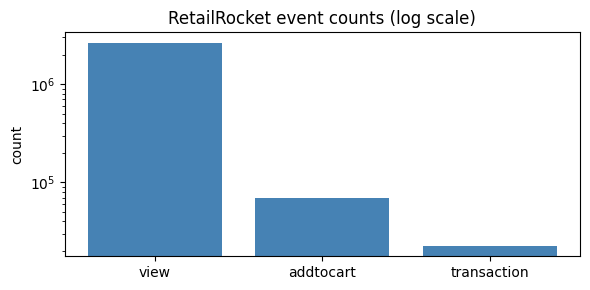

In [13]:
import numpy as np
import matplotlib.pyplot as plt

events = list(qa_summary['event_counts'].keys())
counts = [qa_summary['event_counts'][e] for e in events]

plt.figure(figsize=(6, 3))
plt.bar(events, counts, color='steelblue')
plt.yscale('log')
plt.title('RetailRocket event counts (log scale)')
plt.ylabel('count')
plt.tight_layout()


## How we build sequences
We group events by **visitorid** and sort by time. Each sequence contains:
- `times`: timestamps
- `types`: event type ids (`view=0`, `addtocart=1`, `transaction=2`)

Code: `src/datasets/retailrocket.py` (loader)


In [14]:
from src.datasets import EVENT_MAP
EVENT_MAP


{'view': 0, 'addtocart': 1, 'transaction': 2}

## Train/test split (time-based, per visitor)
For each visitor sequence we compute:
- `t_start = first event time`
- `t_end = last event time`
- `split_point = t_start + train_ratio * (t_end - t_start)`

Events with `t <= split_point` go to train; the rest go to test.

Code: `src/utils.py:temporal_train_test_split`


In [15]:
import pandas as pd
from src.utils import temporal_train_test_split

# Show how many visitors have a transaction AFTER the split point (depends on train_ratio + min_events).
pivot = df_grid.pivot(index='min_events', columns='train_ratio', values='with_test_transaction')
pivot


train_ratio,0.5,0.6,0.7,0.8
min_events,,,,
5,4571,4372,4176,3944
10,2067,1951,1830,1700
20,872,812,743,665
30,535,494,452,390
50,294,277,253,217
80,184,172,161,142


### Why do many users have `purchases_test == 0`?
Transactions are rare events. With a time split, many visitors simply have **no transactions in the test window**.
This is *not* necessarily a bug; it's a property of the funnel.


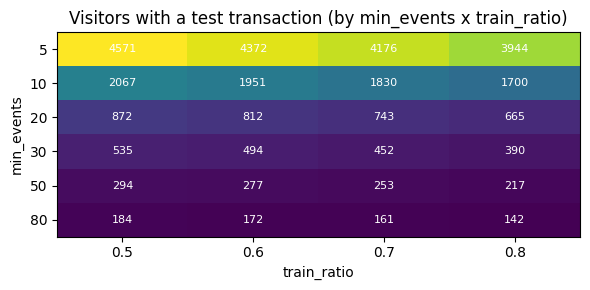

In [16]:
# Optional: visualize the grid as a heatmap
plt.figure(figsize=(6, 3))
z = pivot.values.astype(float)
plt.imshow(z, aspect='auto')
plt.title('Visitors with a test transaction (by min_events x train_ratio)')
plt.xlabel('train_ratio')
plt.ylabel('min_events')
plt.xticks(range(pivot.shape[1]), [str(c) for c in pivot.columns])
plt.yticks(range(pivot.shape[0]), [str(i) for i in pivot.index])
for i in range(z.shape[0]):
    for j in range(z.shape[1]):
        plt.text(j, i, str(int(z[i, j])), ha='center', va='center', fontsize=8, color='white')
plt.tight_layout()


## Inspect one real visitor timeline
We pick a visitor from the latest experiment run (with at least one test transaction) and plot their event timeline with the split point.


In [17]:
# Pick latest run automatically (or set RUN_ID manually)
RUN_ID = None  # e.g. 'retailrocket-20260126-183513'
runs = sorted((ROOT / 'results/retailrocket').glob('retailrocket-*'))
if not runs:
    raise FileNotFoundError('No runs found under results/retailrocket/. Run: scripts/run_real.py')
RUN_DIR = (ROOT / 'results/retailrocket' / RUN_ID) if RUN_ID else runs[-1]

df_run = pd.read_csv(RUN_DIR / 'summary.csv')
print('RUN_DIR:', RUN_DIR)
print('rows:', len(df_run))
print('purchases_test==0:', int((df_run.purchases_test == 0).sum()))

cand = df_run[df_run.purchases_test > 0].sort_values('ll_gain', ascending=False)
if len(cand) == 0:
    raise ValueError('No sequences with purchases_test>0 in this run. Try another RUN_ID or change train_ratio.')
seq_id = int(cand.iloc[0].seq_id)
print('Example seq_id (visitorid):', seq_id)


RUN_DIR: /Users/amosh239/repo/mkn/Hawk's proccess/results/retailrocket/retailrocket-20260127-132934
rows: 48
purchases_test==0: 2
Example seq_id (visitorid): 974226


In [18]:
# Load events for one visitor (streaming read; avoids loading the full 2.7M rows in RAM)
def load_visitor_events(path, visitorid, chunksize=500_000):
    usecols = ['timestamp', 'visitorid', 'event']
    parts = []
    for chunk in pd.read_csv(path, usecols=usecols, chunksize=chunksize):
        m = chunk['visitorid'].astype('int64') == int(visitorid)
        if m.any():
            parts.append(chunk.loc[m, usecols])
    if not parts:
        return pd.DataFrame(columns=usecols + ['ts', 'type_id'])
    df = pd.concat(parts, ignore_index=True)
    df = df[df['event'].isin(EVENT_MAP.keys())].copy()
    df['ts'] = pd.to_datetime(df['timestamp'], unit='ms')
    df['type_id'] = df['event'].map(EVENT_MAP)
    return df.sort_values('ts')

df_v = load_visitor_events(DATA_PATH, seq_id)
print('events:', len(df_v))
print(df_v['event'].value_counts())


events: 694
event
view           596
addtocart       53
transaction     45
Name: count, dtype: int64


In [19]:
# Compute split point (same logic as src/utils.py:temporal_train_test_split)
train_ratio = 0.8
times = df_v['ts'].tolist()
types = df_v['type_id'].tolist()
train_times, test_times, train_types, test_types = temporal_train_test_split(times, types, train_ratio=train_ratio)

t_start = times[0]
duration_sec = (times[-1] - t_start).total_seconds()
split_point = t_start + pd.Timedelta(seconds=duration_sec * train_ratio)

p_train = sum(int(x == EVENT_MAP['transaction']) for x in (train_types or []))
p_test = sum(int(x == EVENT_MAP['transaction']) for x in (test_types or []))

print('train_ratio:', train_ratio)
print('split_point:', split_point)
print('purchases_train:', p_train)
print('purchases_test:', p_test)


train_ratio: 0.8
split_point: 2015-07-16 15:18:16.264200
purchases_train: 39
purchases_test: 6


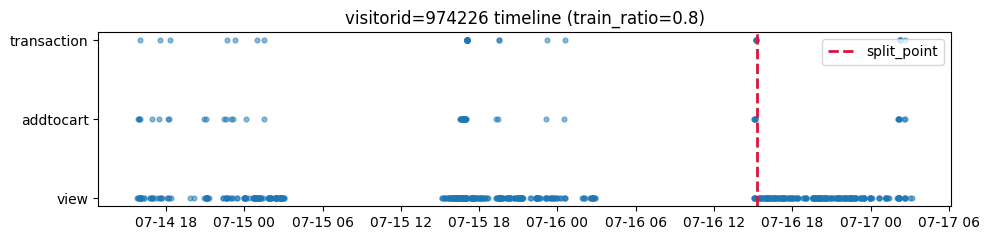

In [20]:
plt.figure(figsize=(10, 2.5))
plt.scatter(df_v['ts'], df_v['type_id'], s=12, alpha=0.5)
plt.axvline(split_point, color='crimson', linestyle='--', linewidth=2, label='split_point')
plt.yticks([0, 1, 2], ['view', 'addtocart', 'transaction'])
plt.title(f'visitorid={seq_id} timeline (train_ratio={train_ratio})')
plt.legend(loc='upper right')
plt.tight_layout()


## Experiment selection funnel (why 1.4M users -> ~50)

This repo is *not* training on all 1.4M visitors. We apply multiple filters and often also cap `--max-seqs`.

Key places to check:
- Loader filters: `src/datasets/retailrocket.py:6-33`
- Experiment filters: `src/experiments.py:93-151`


In [21]:
import pandas as pd
import numpy as np

# Match the flags you used for the run you want to explain
MIN_EVENTS = 30
MAX_SEQS = 50
TRAIN_RATIO = 0.8
MIN_TRAIN_EVENTS = 20
MIN_PURCHASES_TRAIN = 2

# Pick a run to explain (set RUN_ID manually if needed)
RUN_ID = None  # e.g. 'retailrocket-20260127-132934'
runs = sorted((ROOT / 'results/retailrocket').glob('retailrocket-*'))
RUN_DIR = (ROOT / 'results/retailrocket' / RUN_ID) if RUN_ID else runs[-1]
df_run = pd.read_csv(RUN_DIR / 'summary.csv')

print('RUN_DIR:', RUN_DIR)
print('final rows in summary.csv:', len(df_run))

# 1) Total visitors (from full-file QA)
total_visitors = int(qa_summary['unique_visitors'])

# 2) Visitors with >= MIN_EVENTS (full file)
df_ge = df_grid[(df_grid.min_events == MIN_EVENTS) & (df_grid.train_ratio == TRAIN_RATIO)]
vis_ge_min = int(df_ge.visitors_ge_min.iloc[0]) if len(df_ge) else None

print('total_visitors:', total_visitors)
print('visitors_ge_min_events:', vis_ge_min)

# 3) Visitors with >= MIN_EVENTS and ANY transaction (full file; quick pass)
usecols = ['visitorid', 'event']
df = pd.read_csv(DATA_PATH, usecols=usecols)
df = df[df['event'].isin(['view', 'addtocart', 'transaction'])]

counts = df.groupby('visitorid', sort=False).size()
counts_tx = df.loc[df['event'] == 'transaction'].groupby('visitorid', sort=False).size()

eligible = counts[counts >= MIN_EVENTS].index
eligible_tx = eligible.intersection(counts_tx.index)

print('visitors_ge_min_events_with_any_transaction:', int(len(eligible_tx)))

# 4) If MAX_SEQS is set, loader currently takes TOP by total event count (bias toward very active users).
if MAX_SEQS is not None:
    top = counts.loc[eligible_tx].sort_values(ascending=False).head(int(MAX_SEQS))
    print('after --max-seqs (top by count):', int(len(top)))
    print('top n_events summary (min/median/max):', int(top.min()), int(top.median()), int(top.max()))

# 5) After loader, `run_purchase_experiment` also filters by split+train window sizes and min purchases in train.
print('experiment filters:', {'min_train_events': MIN_TRAIN_EVENTS, 'min_purchases_train': MIN_PURCHASES_TRAIN, 'train_ratio': TRAIN_RATIO})


RUN_DIR: /Users/amosh239/repo/mkn/Hawk's proccess/results/retailrocket/retailrocket-20260127-132934
final rows in summary.csv: 48
total_visitors: 1407580
visitors_ge_min_events: 3173
visitors_ge_min_events_with_any_transaction: 947
after --max-seqs (top by count): 50
top n_events summary (min/median/max): 604 1036 7757
experiment filters: {'min_train_events': 20, 'min_purchases_train': 2, 'train_ratio': 0.8}


### Is `--max-seqs` selecting “top active”?
Yes: the loader explicitly sorts eligible visitors by event count when `max_sequences` is set.


In [22]:
from pathlib import Path

path = ROOT / 'src/datasets/retailrocket.py'
lines = path.read_text(encoding='utf-8').splitlines()
start, end = 18, 45  # show the selection block with line numbers
for i in range(start, min(end, len(lines))):
    print(f'{i+1:4d}: {lines[i]}')


  19:     df["type_id"] = df["event"].map(EVENT_MAP)
  20:     df = df.sort_values([group, "ts"])
  21: 
  22:     if min_events is not None or require_transaction:
  23:         counts = df.groupby(group, sort=False).size()
  24:         eligible = counts.index
  25:         if min_events is not None:
  26:             eligible = counts[counts >= int(min_events)].index
  27:         if require_transaction:
  28:             counts_tx = df.loc[df["event"] == "transaction"].groupby(group, sort=False).size()
  29:             eligible = eligible.intersection(counts_tx.index)
  30:         if max_sequences is not None:
  31:             eligible = counts.loc[eligible].sort_values(ascending=False).index[: int(max_sequences)]
  32:         df = df[df[group].isin(eligible)]
  33: 
  34:     sequences = []
  35:     for idx, (_, g) in enumerate(df.groupby(group)):
  36:         times = g["ts"].tolist()
  37:         types = g["type_id"].tolist()
  38:         sequences.append({"id": g[group].

## Why “it suddenly became very good”

We check three suspects:
1) Selection bias (are we sampling only very active buyers?)
2) Baseline sparsity (many near-zero bins in hour-of-week?)
3) Metric bug (denominator cast to `int(test_hours)`)


In [23]:
import pandas as pd

RUN_NEW = RUN_DIR.name
RUN_OLD = 'retailrocket-20260126-183513'

def quick_dist(df, cols):
    out = {}
    for c in cols:
        if c not in df.columns or len(df) == 0:
            continue
        out[c] = {
            'mean': float(df[c].mean()),
            'median': float(df[c].median()),
            'p90': float(df[c].quantile(0.9)),
        }
    return out

df_new = pd.read_csv(ROOT / 'results/retailrocket' / RUN_NEW / 'summary.csv')
df_old = pd.read_csv(ROOT / 'results/retailrocket' / RUN_OLD / 'summary.csv')

cols = ['n_events', 'purchases_train', 'purchases_test', 'test_hours', 'll_gain']
print('RUN_NEW:', RUN_NEW, 'rows:', len(df_new))
print(quick_dist(df_new, cols))
print()
print('RUN_OLD:', RUN_OLD, 'rows:', len(df_old))
print(quick_dist(df_old, cols))


RUN_NEW: retailrocket-20260127-132934 rows: 48
{'n_events': {'mean': 1488.0208333333333, 'median': 1036.0, 'p90': 2364.5000000000005}, 'purchases_train': {'mean': 70.10416666666667, 'median': 51.0, 'p90': 122.40000000000012}, 'purchases_test': {'mean': 22.375, 'median': 16.0, 'p90': 55.400000000000034}, 'test_hours': {'mean': 274.4836166550926, 'median': 168.08487694444443, 'p90': 658.0226814722223}, 'll_gain': {'mean': 0.424096198009085, 'median': 0.36963367209074643, 'p90': 0.7802639178586563}}

RUN_OLD: retailrocket-20260126-183513 rows: 78
{'n_events': {'mean': 260.1025641025641, 'median': 57.0, 'p90': 818.2999999999998}, 'purchases_train': {'mean': 13.807692307692308, 'median': 3.0, 'p90': 28.799999999999983}, 'purchases_test': {'mean': 5.410256410256411, 'median': 0.0, 'p90': 7.299999999999997}, 'test_hours': {'mean': 550.2503625854702, 'median': 314.07824138888884, 'p90': 1352.8946452777777}, 'll_gain': {'mean': -2.248836198837291, 'median': 0.00888024754670105, 'p90': 0.6156120

In [24]:
# Gain breakdown: does it come from sequences with purchases in test?
def gain_groups(df):
    A = df[df.purchases_test > 0]
    B = df[df.purchases_test == 0]
    def s(x):
        if len(x) == 0:
            return None
        return {
            'n': int(len(x)),
            'win_rate': float((x.ll_gain > 0).mean()),
            'll_gain_mean': float(x.ll_gain.mean()),
            'll_gain_median': float(x.ll_gain.median()),
        }
    return {'A_purchases_test_gt0': s(A), 'B_purchases_test_eq0': s(B)}

print('RUN_NEW groups:', gain_groups(df_new))
print('RUN_OLD groups:', gain_groups(df_old))


RUN_NEW groups: {'A_purchases_test_gt0': {'n': 46, 'win_rate': 1.0, 'll_gain_mean': 0.43699026366008903, 'll_gain_median': 0.3807968684647593}, 'B_purchases_test_eq0': {'n': 2, 'win_rate': 1.0, 'll_gain_mean': 0.1275326880359917, 'll_gain_median': 0.1275326880359917}}
RUN_OLD groups: {'A_purchases_test_gt0': {'n': 23, 'win_rate': 0.9565217391304348, 'll_gain_mean': 2.3998047385049355, 'll_gain_median': 0.3070867375249411}, 'B_purchases_test_eq0': {'n': 55, 'win_rate': 0.7090909090909091, 'll_gain_mean': -4.1928133180894935, 'll_gain_median': 0.0029761871997189}}


## Baseline sparsity check (hour-of-week / 168 bins)

If many purchases fall into bins where the baseline rate is at the numeric floor (`1e-8`), Hawkes can win “for free”.


In [25]:
import pandas as pd
import numpy as np

from src.baselines import HourOfWeekSeasonalPoisson
from src.datasets.retailrocket import EVENT_MAP
from src.utils import temporal_train_test_split

def load_events_for_visitors(path, visitor_ids, chunksize=500_000):
    usecols = ['timestamp', 'visitorid', 'event']
    by_vid = {int(v): [] for v in visitor_ids}
    visitor_ids = set(int(v) for v in visitor_ids)
    for chunk in pd.read_csv(path, usecols=usecols, chunksize=chunksize):
        chunk = chunk[chunk['visitorid'].isin(visitor_ids)]
        if chunk.empty:
            continue
        chunk = chunk[chunk['event'].isin(EVENT_MAP.keys())]
        if chunk.empty:
            continue
        chunk['ts'] = pd.to_datetime(chunk['timestamp'], unit='ms')
        chunk['type_id'] = chunk['event'].map(EVENT_MAP)
        for vid, g in chunk.groupby('visitorid'):
            by_vid[int(vid)].extend(zip(g['ts'].tolist(), g['type_id'].tolist()))
    return by_vid

def hour_of_week_idx(ts):
    return int(ts.dayofweek) * 24 + int(ts.hour)

def baseline_sparsity_for_run(run_id, train_ratio=0.8):
    df = pd.read_csv(ROOT / 'results/retailrocket' / run_id / 'summary.csv')
    vids = [int(v) for v in df.seq_id.astype(int).tolist()]
    by_vid = load_events_for_visitors(DATA_PATH, vids)

    pooled_train = []
    pooled_test = []
    for vid, evs in by_vid.items():
        evs = sorted(evs, key=lambda x: x[0])
        times = [t for t, _ in evs]
        types = [tp for _, tp in evs]
        if not times:
            continue
        train_times, test_times, train_types, test_types = temporal_train_test_split(times, types, train_ratio=train_ratio)
        pooled_train.extend([t for t, tp in zip(train_times, train_types) if tp == EVENT_MAP['transaction']])
        pooled_test.extend([t for t, tp in zip(test_times, test_types) if tp == EVENT_MAP['transaction']])

    pooled_train = sorted(pooled_train)
    pooled_test = sorted(pooled_test)
    base = HourOfWeekSeasonalPoisson().fit(pooled_train)
    rates = base.rates
    floor = 1e-8
    floor_mask = rates <= floor

    def count_in_floor(ts_list):
        if not ts_list:
            return 0
        idx = np.asarray([hour_of_week_idx(t) for t in ts_list], dtype=int)
        return int(np.sum(floor_mask[idx]))

    in_floor_train = count_in_floor(pooled_train)
    in_floor_test = count_in_floor(pooled_test)

    return {
        'run_id': run_id,
        'pooled_purchases_train': int(len(pooled_train)),
        'pooled_purchases_test': int(len(pooled_test)),
        'frac_bins_at_floor': float(floor_mask.mean()),
        'min_rate': float(rates.min()),
        'max_rate': float(rates.max()),
        'purchases_train_in_floor_bins': int(in_floor_train),
        'purchases_test_in_floor_bins': int(in_floor_test),
        'share_test_in_floor_bins': float(in_floor_test / len(pooled_test)) if pooled_test else None,
    }

print(baseline_sparsity_for_run(RUN_NEW, train_ratio=TRAIN_RATIO))


{'run_id': 'retailrocket-20260127-132934', 'pooled_purchases_train': 3365, 'pooled_purchases_test': 1074, 'frac_bins_at_floor': 0.4642857142857143, 'min_rate': 1e-08, 'max_rate': 5.362019367088307, 'purchases_train_in_floor_bins': 0, 'purchases_test_in_floor_bins': 0, 'share_test_in_floor_bins': 0.0}


## Metric sanity: `test_hours` denominator casting bug

Previously `calc_test_ll` casted `denom` via `int(denom)`. That can break sequences with short test windows (`test_hours < 1` -> denom=0) and slightly shifts scaling for others.
Fix: `src/experiments.py` now uses `float(denom)`.


In [26]:
# Compare the run produced *before* vs *after* the denom fix (same flags).
RUN_BEFORE = 'retailrocket-20260127-121701'  # produced with int(test_hours)
RUN_AFTER = RUN_NEW  # should be produced with float(test_hours)

df_b = pd.read_csv(ROOT / 'results/retailrocket' / RUN_BEFORE / 'summary.csv')
df_a = pd.read_csv(ROOT / 'results/retailrocket' / RUN_AFTER / 'summary.csv')

def ll_gain_stats(df):
    return {
        'rows': int(len(df)),
        'mean': float(df.ll_gain.mean()) if len(df) else None,
        'median': float(df.ll_gain.median()) if len(df) else None,
        'min': float(df.ll_gain.min()) if len(df) else None,
        'max': float(df.ll_gain.max()) if len(df) else None,
    }

print('BEFORE:', RUN_BEFORE, ll_gain_stats(df_b))
print('AFTER: ', RUN_AFTER, ll_gain_stats(df_a))


BEFORE: retailrocket-20260127-121701 {'rows': 48, 'mean': 0.4258672169789312, 'median': 0.37113743042181074, 'min': 0.0015388094899518, 'max': 2.5245765069629535}
AFTER:  retailrocket-20260127-132934 {'rows': 48, 'mean': 0.424096198009085, 'median': 0.36963367209074643, 'min': 0.0015342919677159, 'max': 2.5233591030179285}


## Short test windows: instability check

Very small `test_hours` can make `ll_gain (per hour)` numerically unstable (a few purchases divided by a small number).


corr(ll_gain, test_hours) for RUN_NEW: -0.4984361805668281


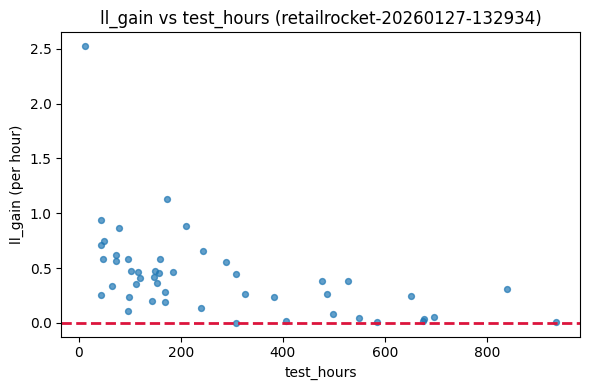

In [27]:
import numpy as np
import matplotlib.pyplot as plt

corr = float(np.corrcoef(df_new.test_hours.values, df_new.ll_gain.values)[0, 1])
print('corr(ll_gain, test_hours) for RUN_NEW:', corr)

plt.figure(figsize=(6, 4))
plt.scatter(df_new.test_hours, df_new.ll_gain, s=18, alpha=0.7)
plt.axhline(0, color='crimson', linestyle='--', linewidth=2)
plt.xlabel('test_hours')
plt.ylabel('ll_gain (per hour)')
plt.title(f'll_gain vs test_hours ({RUN_NEW})')
plt.tight_layout()
